##Setup

In [4]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/opt/anaconda3/lib/python3.13/site-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [5]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)


def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()

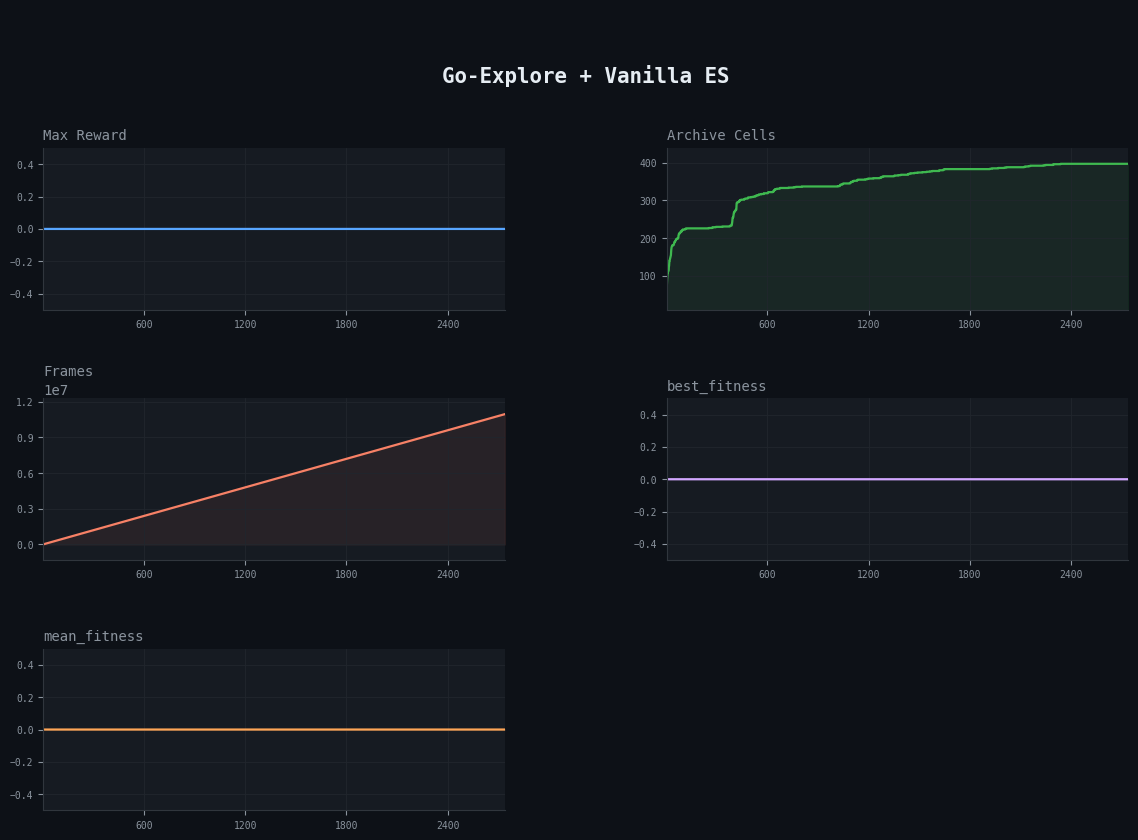

In [ ]:
from collections import defaultdict
import numpy as np
import cv2
import gymnasium as gym
import ale_py
import random
import copy
import torch
import torch.nn as nn

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'frames', 'best_fitness', 'mean_fitness'],
    title='Go-Explore + Vanilla ES', update_every=1,
)

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# Policy Network
#
# ES never calls .backward() — no gradients flow through this network.
# Parameters are manipulated directly as flat numpy vectors.
# ──────────────────────────────────────────────
class PolicyNet(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             nn.ReLU(),
        )
        with torch.no_grad():
            feature_size = self.conv(
                torch.zeros(1, *input_shape)
            ).reshape(1, -1).size(1)

        self.fc = nn.Sequential(
            nn.Linear(feature_size, 256), nn.ReLU(),
            nn.Linear(256, n_actions),
        )

    def forward(self, x):
        x = x.float() / 255.
        return self.fc(self.conv(x).reshape(x.size(0), -1))

    def act(self, state_np, device):
        """Deterministic greedy action — ES policies don't need stochasticity."""
        with torch.no_grad():
            t = torch.from_numpy(state_np).permute(2, 0, 1).unsqueeze(0).to(device)
            return self.forward(t).argmax(1).item()

    def get_params(self):
        """Flat numpy parameter vector — the θ that ES optimises."""
        return np.concatenate([p.data.cpu().numpy().ravel()
                               for p in self.parameters()])

    def set_params(self, flat_params):
        """Load a flat numpy parameter vector back into the network."""
        offset = 0
        for p in self.parameters():
            size = p.numel()
            p.data.copy_(
                torch.from_numpy(
                    flat_params[offset : offset + size].reshape(p.shape)
                ).float()
            )
            offset += size


# ──────────────────────────────────────────────
# Vanilla Evolution Strategies
#
# Implements the algorithm from:
#   "Evolution Strategies as a Scalable Alternative to Reinforcement Learning"
#   Salimans, Ho, Chen, Sidor, Sutskever — OpenAI, 2017
#
# Core idea:
#   ES maintains a single mean parameter vector θ.
#   Each generation, N perturbations εi ~ N(0, I) are sampled.
#   Perturbed policies θ + σεi are evaluated for fitness F_i.
#   θ is updated using the fitness-weighted sum of perturbations:
#
#       θ ← θ + α · (1 / Nσ) · Σ_i F_i · εi
#
#   This is an unbiased estimate of ∇_θ E[F(θ + σε)]:
#       ∇_θ E[F(θ+σε)] = (1/σ) E[F(θ+σε) · ε]
#
# Three practical additions from the paper:
#
#   1. Antithetic sampling (mirrored perturbations):
#      For each noise vector εi, also evaluate θ - σεi.
#      The paired evaluations have negatively correlated noise,
#      halving estimator variance at the same population budget.
#      N must be even; half are positive, half negative perturbations.
#
#   2. Fitness rank normalisation:
#      Replace raw fitness scores with centred ranks in [-0.5, 0.5].
#      This removes scale sensitivity — a rare reward of 100 no longer
#      dominates updates compared to a common reward of 0.01.
#      It also acts as a soft outlier filter.
#
#   3. Adam optimiser on the gradient estimate:
#      The ES gradient estimate (1/Nσ) Σ F_i εi is passed to Adam
#      rather than a fixed learning rate. Adam's adaptive moments
#      smooth noisy gradient estimates and accelerate convergence
#      in the early generations when fitness variance is high.
# ──────────────────────────────────────────────
class VanillaES:
    def __init__(self, theta_init, pop_size, sigma, lr,
                 adam_beta1=0.9, adam_beta2=0.999, adam_eps=1e-8):
        assert pop_size % 2 == 0, "pop_size must be even for antithetic sampling"

        self.theta     = theta_init.astype(np.float32).copy()
        self.pop_size  = pop_size          # total evaluations per generation (N)
        self.n_pairs   = pop_size // 2     # antithetic pairs
        self.sigma     = sigma             # perturbation std
        self.lr        = lr

        # Adam state
        self.t      = 0
        self.m      = np.zeros_like(self.theta)   # first moment
        self.v      = np.zeros_like(self.theta)   # second moment
        self.beta1  = adam_beta1
        self.beta2  = adam_beta2
        self.eps    = adam_eps

        # Noise matrix reused across the generation — shape (n_pairs, n_params)
        self._noise = None

    # ── Perturbation sampling ────────────────────────────────────────────────
    def sample_perturbations(self):
        """
        Sample n_pairs noise vectors. Returns (n_pairs, n_params) array.
        Each pair contributes two evaluations: θ + σε and θ - σε.
        Noise is stored so update() can reference the same vectors.
        """
        self._noise = np.random.randn(self.n_pairs, len(self.theta)).astype(np.float32)
        return self._noise

    def get_candidate(self, pair_idx, positive=True):
        """Return θ + σε (positive=True) or θ - σε (positive=False)."""
        sign = 1.0 if positive else -1.0
        return self.theta + sign * self.sigma * self._noise[pair_idx]

    # ── Rank normalisation ───────────────────────────────────────────────────
    @staticmethod
    def _rank_normalise(fitnesses):
        """
        Map raw fitness scores to centred ranks in [-0.5, 0.5].

        Steps:
          1. Argsort to get rank order.
          2. Assign ranks 0, 1, ..., N-1.
          3. Normalise to [0, 1]: rank / (N - 1).
          4. Centre to [-0.5, 0.5]: subtract 0.5.

        This makes the update invariant to the fitness scale — a single
        high-reward episode no longer dominates the gradient estimate,
        and the update magnitude is consistent across generations.
        """
        n       = len(fitnesses)
        ranks   = np.empty(n, dtype=np.float32)
        order   = np.argsort(fitnesses)
        ranks[order] = np.arange(n)
        return ranks / (n - 1) - 0.5

    # ── Parameter update ────────────────────────────────────────────────────
    def update(self, pos_fitnesses, neg_fitnesses):
        """
        Compute the ES gradient estimate and update θ via Adam.

        pos_fitnesses : (n_pairs,) fitness for θ + σεi evaluations
        neg_fitnesses : (n_pairs,) fitness for θ - σεi evaluations

        The antithetic gradient estimate is:
            g = (1 / 2·n_pairs·σ) · Σ_i (F(θ+σεi) - F(θ-σεi)) · εi

        Using the fitness *difference* between mirrored pairs removes the
        baseline (the mean fitness cancels) and further reduces variance.
        Rank normalisation is applied to the combined 2N fitness values
        before computing the difference, preserving ordinal information
        while making the update scale-invariant.
        """
        # Combine and rank-normalise all 2N fitness values together
        all_fits   = np.concatenate([pos_fitnesses, neg_fitnesses])
        all_ranked = self._rank_normalise(all_fits)
        pos_ranked = all_ranked[:self.n_pairs]
        neg_ranked = all_ranked[self.n_pairs:]

        # Antithetic gradient estimate: weight each noise vector by
        # the fitness difference between its positive and negative perturbation
        fitness_diff = pos_ranked - neg_ranked          # (n_pairs,)
        grad_est = (fitness_diff[:, None] * self._noise).sum(axis=0)
        grad_est /= (2 * self.n_pairs * self.sigma)     # normalise by population

        # Adam update on the gradient estimate
        self.t += 1
        self.m  = self.beta1 * self.m + (1 - self.beta1) * grad_est
        self.v  = self.beta2 * self.v + (1 - self.beta2) * grad_est ** 2
        m_hat   = self.m / (1 - self.beta1 ** self.t)
        v_hat   = self.v / (1 - self.beta2 ** self.t)

        # Gradient ascent (maximise fitness)
        self.theta += self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

        return float(np.linalg.norm(grad_est))   # gradient norm for logging


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()


def select_cell_from_archive(archive):
    hashes = list(archive.keys())
    scores = np.array([archive[h].score for h in hashes])
    probs  = scores / scores.sum()
    return hashes[np.random.choice(len(hashes), p=probs)]


# ──────────────────────────────────────────────
# Evaluate one candidate policy
# ──────────────────────────────────────────────
def evaluate_candidate(env, net, device, archive, start_ram, start_score,
                        start_trajectory, eval_steps):
    """
    Returns (fitness, found_new_cell).
    Fitness = reward accumulated beyond the restored cell's baseline score.
    """
    state         = restore_env(env, start_ram)
    score         = start_score
    trajectory    = start_trajectory.copy()
    current_lives = get_lives(env)
    found_new     = False

    for _ in range(eval_steps):
        action     = net.act(state, device)
        next_state, reward, terminal, truncated, _ = env.step(action)

        new_lives = get_lives(env)
        life_lost = new_lives < current_lives
        done      = terminal or truncated or life_lost
        current_lives = new_lives

        score += reward
        trajectory.append(action)

        if done:
            break

        cell_repr   = cellfn(next_state)
        cellhash    = hashfn(cell_repr)
        cell        = archive[cellhash]
        first_visit = cell.visit()

        cell_reward = getattr(cell, 'reward',     -1e9)
        cell_traj   = getattr(cell, 'trajectory', [])
        better  = score > cell_reward
        shorter = score == cell_reward and len(trajectory) < len(cell_traj)

        if first_visit or better or shorter:
            cell.ram        = env.unwrapped.ale.cloneState()
            cell.reward     = score
            cell.trajectory = trajectory.copy()
            cell.times_chosen           = 0
            cell.times_chosen_since_new = 0
            found_new = True

        state = next_state

    fitness = score - start_score
    return fitness, found_new


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
POP_SIZE    = 20      # Total evaluations per generation (must be even)
SIGMA       = 0.01    # Perturbation noise std (Salimans et al. use 0.01–0.05)
LR          = 0.01    # Adam learning rate on the gradient estimate
EVAL_STEPS  = 200     # Max steps per candidate evaluation
WARMUP_GENS = 10      # Generations of random archive seeding before ES updates

# ──────────────────────────────────────────────
# Setup
# ──────────────────────────────────────────────
archive   = defaultdict(lambda: Cell())
highscore = 0
frames    = 0

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

env       = gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')
obs       = env.observation_space.shape
n_actions = env.action_space.n
input_shape = (obs[2], obs[0], obs[1])

# Seed the archive with a short random episode
state, _      = env.reset()
current_lives = get_lives(env)
seed_score    = 0
seed_traj     = []
for _ in range(500):
    action = env.action_space.sample()
    next_state, reward, terminal, truncated, _ = env.step(action)
    new_lives  = get_lives(env)
    done       = terminal or truncated or new_lives < current_lives
    current_lives = new_lives
    seed_score += reward
    seed_traj.append(action)
    frames += 1
    if not done:
        h    = hashfn(cellfn(next_state))
        cell = archive[h]
        first_visit = cell.visit()
        if first_visit or seed_score > getattr(cell, 'reward', -1e9):
            cell.ram        = env.unwrapped.ale.cloneState()
            cell.reward     = seed_score
            cell.trajectory = seed_traj.copy()
            cell.times_chosen           = 0
            cell.times_chosen_since_new = 0
        state = next_state
    else:
        state, _      = env.reset()
        current_lives = get_lives(env)
        seed_score    = 0
        seed_traj     = []

# Initialise mean policy θ and ES
mean_net = PolicyNet(input_shape, n_actions).to(device)
es       = VanillaES(
    theta_init = mean_net.get_params(),
    pop_size   = POP_SIZE,
    sigma      = SIGMA,
    lr         = LR,
)

# Reusable candidate network (parameters swapped each evaluation)
candidate_net = PolicyNet(input_shape, n_actions).to(device)
generation    = 0

# ──────────────────────────────────────────────
# Main loop — one iteration = one generation
# ──────────────────────────────────────────────
while True:
    found_new_any = False

    # ── Sample perturbations for this generation ──────────────────────────────
    noise = es.sample_perturbations()   # (n_pairs, n_params)
    pos_fitnesses = np.zeros(es.n_pairs, dtype=np.float32)
    neg_fitnesses = np.zeros(es.n_pairs, dtype=np.float32)
    all_fitnesses = []

    # ── Evaluate antithetic pairs ─────────────────────────────────────────────
    # Each pair is restored to a different archive cell so the population
    # collectively covers the archive frontier rather than all starting from
    # the same state. Positive and negative perturbations of the same pair
    # are evaluated from the SAME cell — this is intentional: the fitness
    # difference (pos - neg) isolates the effect of the perturbation direction
    # independent of which cell was chosen.
    for pair_idx in range(es.n_pairs):
        if len(archive) > 0:
            h    = select_cell_from_archive(archive)
            cell = archive[h]
            ram, start_score, start_traj = cell.choose()
        else:
            env.reset()
            ram, start_score, start_traj = env.unwrapped.ale.cloneState(), 0, []

        # Positive perturbation: θ + σε
        candidate_net.set_params(es.get_candidate(pair_idx, positive=True))
        pos_fit, found_pos = evaluate_candidate(
            env, candidate_net, device,
            archive, ram, start_score, start_traj, EVAL_STEPS
        )

        # Negative perturbation: θ - σε (same cell, same start)
        candidate_net.set_params(es.get_candidate(pair_idx, positive=False))
        neg_fit, found_neg = evaluate_candidate(
            env, candidate_net, device,
            archive, ram, start_score, start_traj, EVAL_STEPS
        )

        pos_fitnesses[pair_idx] = pos_fit
        neg_fitnesses[pair_idx] = neg_fit
        all_fitnesses.extend([pos_fit + start_score, neg_fit + start_score])
        frames += 2 * EVAL_STEPS  # approximate

        total_pos = start_score + pos_fit
        total_neg = start_score + neg_fit
        if max(total_pos, total_neg) > highscore:
            highscore = max(total_pos, total_neg)

        if found_pos or found_neg:
            found_new_any = True

    # ── ES update ─────────────────────────────────────────────────────────────
    if generation >= WARMUP_GENS:
        grad_norm = es.update(pos_fitnesses, neg_fitnesses)
        # Sync the mean network with the updated θ for archive evaluation / logging
        mean_net.set_params(es.theta)

    best_fitness = float(max(all_fitnesses))
    mean_fitness = float(np.mean(all_fitnesses))
    generation  += 1

    print(
        f"Gen: {generation:5d} | Cells: {len(archive):5d} | "
        f"Frames: {frames:8d} | MaxReward: {highscore:.1f} | "
        f"BestFit: {best_fitness:.2f} | MeanFit: {mean_fitness:.2f}"
    )

    dashboard.update(
        iteration    = generation,
        frames       = frames,
        max_reward   = highscore,
        cells        = len(archive),
        best_fitness = best_fitness,
        mean_fitness = mean_fitness,
    )